In [1]:
import numpy as np
import sympy as sp
import math
import matplotlib.pyplot as plt

In [2]:

#Usando método da bissecção
equacao = lambda x:x*np.log(x)

ini_intervalo = 2
fim_intervalo = 4
erro = 10**-3
max_iteracao = 6
ponto_med = lambda ini_intervalo,fim_intervalo: (ini_intervalo+fim_intervalo)/2
for i in range(max_iteracao):

  new_x = ponto_med(ini_intervalo,fim_intervalo)
  erro_at = abs(ini_intervalo-fim_intervalo)/ max(1,abs(fim_intervalo))
  if erro_at < erro:
    print(f"A raiz está em {new_x}")
    break
  elif equacao(ini_intervalo)*equacao(new_x) < 0:
    fim_intervalo = new_x
  else:
    ini_intervalo = new_x
  #só exec o else se o loop for concluido, o else pd ser anexado a um loop
else:
  print("Não chegou no erro após",max_iteracao,"iterações. Última aproximação foi",new_x)


Não chegou no erro após 6 iterações. Última aproximação foi 3.96875


In [3]:
ponto_med = lambda ini_intervalo,fim_intervalo: (ini_intervalo+fim_intervalo)/2
def bisseccao_(ini_intervalo,fim_intervalo,erro,max_iteracao,equacao):
  for i in range(max_iteracao):

    new_x = ponto_med(ini_intervalo,fim_intervalo)
    erro_at = abs(ini_intervalo-fim_intervalo)/ max(1,abs(fim_intervalo))
    if erro_at < erro:
      print(f"A raiz está em {new_x}")
      return new_x,i+1
    elif equacao(ini_intervalo)*equacao(new_x) < 0:
      fim_intervalo = new_x
    else:
      ini_intervalo = new_x
  #só exec o else se o loop for concluido, o else pd ser anexado a um loop
  else:
    print("Não chegou no erro após",max_iteracao,"iterações. Última aproximação foi",new_x)
    return new_x, max_iteracao # Retorna a última aproximação e o número máximo de iterações

bisseccao_(2,4,10**-3,4,lambda x:x-x*math.log(x))
bisseccao_(0,1,1e-3,100,lambda x:x*math.exp(-x) -math.exp(-3))

Não chegou no erro após 4 iterações. Última aproximação foi 2.625
A raiz está em 0.05224609375


(0.05224609375, 11)

In [4]:
#Meu da posi_falsa
def posi_falsa(ini_intervalo,fim_intervalo,erro,max_iteracao,equacao):
  for i in range(max_iteracao):
    denominador = equacao(fim_intervalo) - equacao(ini_intervalo)
    if abs(denominador)<1e-10:
      print("Divisão por zero ou denominador muito pequeno")
      break
    new_x = (ini_intervalo*equacao(fim_intervalo)-fim_intervalo*equacao(ini_intervalo))/denominador
    erro_at = abs(equacao(new_x))
    if erro_at < erro:
      print(f"A raiz está em {new_x} após {i+1} iterações. f(raiz) = {equacao(new_x):.6f}")
      return new_x,i+1
    elif equacao(ini_intervalo)*equacao(new_x) < 0:
      fim_intervalo = new_x
    else:
      ini_intervalo = new_x
  #só exec o else se o loop for concluido, o else pd ser anexado a um loop
  else:
    print("Não chegou no erro após",max_iteracao,"iterações. Última aproximação foi",new_x)
    return new_x, max_iteracao # Adicionar retorno explícito

posi_falsa(2,4,10**-3,4,lambda x:x-x*math.log(x))
posi_falsa(0,1,1e-3,100,lambda x:x*math.exp(-x) -math.exp(-3))

A raiz está em 2.717504882823696 após 4 iterações. f(raiz) = 0.000777
A raiz está em 0.05270748726555492 após 3 iterações. f(raiz) = 0.000214


(0.05270748726555492, 3)

In [5]:
ponto_med = lambda ini_intervalo,fim_intervalo: (ini_intervalo+fim_intervalo)/2
#O phi não é genérico para qualquer equação dada
def phi_1(x,equacao):
  return x / math.log(x)

def ponto_fixo(ini_intervalo,fim_intervalo,erro,max_iteracao,equacao):
  chute_ini = ponto_med(ini_intervalo,fim_intervalo)
  xAnt = chute_ini
  for i in range(max_iteracao):
    x_atual = phi_1(xAnt,equacao)
    if np.isnan(x_atual) or np.isinf(x_atual) or x_atual <= 0:
      print(f"O método divergiu na iteração {i+1}. O valor de x se tornou inválido ({x_atual}).")
      return x_atual, i+1
    erro_at = abs(x_atual - xAnt)/max(1,abs(x_atual))

    if erro_at < erro:
      print(f"A raiz está em {x_atual:.6f} após {i+1} iterações. f(raiz) = {equacao(x_atual):.6f}")
      return x_atual,i+1

    xAnt = x_atual
  #só exec o else se o loop for concluido, o else pd ser anexado a um loop
  else:
    print("Não chegou no erro após",max_iteracao,"iterações. Última aproximação foi",x_atual)
    return x_atual, max_iteracao # Adicionar retorno explícito

ponto_fixo(2,4,10**-3,4,lambda x:x-x*math.log(x))

A raiz está em 2.718282 após 3 iterações. f(raiz) = -0.000000


(2.7182818286056407, 3)

In [6]:
#Método de newton
ponto_med = lambda ini_intervalo,fim_intervalo: (ini_intervalo+fim_intervalo)/2
def derivada(equacao,x):
  return sp.diff(equacao,x)

def newton_(ini_intervalo,fim_intervalo,erro,max_iteracao,equacao):
  #O simpy e numpy tem leituras != então é preciso transformas os dados de leituras das funções
  x_simb = sp.Symbol('x')
  #transforma para simpy
  expressao = equacao(x_simb)
  #calc a derivada, a equação
  derivada_simb = derivada(expressao,x_simb)
  #transforma de volta a derivada para numpy, é uma função de derivada da equação fornecida
  derivada_num = sp.lambdify(x_simb,derivada_simb,'numpy')

  chute_ini = ponto_med(ini_intervalo,fim_intervalo)
  xAnt = chute_ini

  for i in range(max_iteracao):
    derivadaEq = derivada_num(xAnt)
    if abs(derivadaEq) < 1e-10:
      print("Divisão por zero ou denominador muito pequeno")
      return xAnt, i+1 # Retorna o último valor conhecido e a iteração atual em caso de divisão por zero

    x_atual = xAnt - equacao(xAnt)/derivadaEq
    x_atual = float(x_atual) # Converte x_atual para float para garantir compatibilidade nas próximas iterações

    erro_at = abs(x_atual - xAnt)/max(1,abs(x_atual))

    if erro_at < erro:
      print(f"A raiz está em {x_atual:.6f} após {i+1} iterações. f(raiz) = {equacao(x_atual):.6f}")
      return x_atual,i+1

    xAnt = x_atual
  #só exec o else se o loop for concluido, o else pd ser anexado a um loop
  else:
    print("Não chegou no erro após",max_iteracao,"iterações. Última aproximação foi",x_atual)
    return x_atual, max_iteracao # Adicionar retorno explícito

newton_(2,4,10**-3,4,lambda x:x-x*sp.log(x))
newton_(0,1,1e-3,100,lambda x:x*sp.exp(-x) -sp.exp(-3))

A raiz está em 2.718282 após 3 iterações. f(raiz) = -0.000000
A raiz está em 0.052469 após 5 iterações. f(raiz) = 0.000000


(0.052469080762489004, 5)

In [7]:
#Método da Secante
ponto_med = lambda ini_intervalo,fim_intervalo: (ini_intervalo+fim_intervalo)/2
def secante(ini_intervalo,fim_intervalo,erro,max_iteracao,equacao):
  chute1 = ini_intervalo
  chute2 = fim_intervalo
  for i in range(max_iteracao):

    denominador = (equacao(chute2)-equacao(chute1))
    if abs(denominador) < 1e-10:
      print("Divisão por zero ou denominador muito pequeno")
      return float(chute2), i+1 # Retorna o último valor conhecido e a iteração atual em caso de divisão por zero
    new_x = chute2 - (equacao(chute2)*(chute2-chute1))/(denominador)
    erro_at = abs(new_x - chute2)/max(1,abs(new_x))
    if erro_at < erro:
      print(f"A raiz está em {new_x} após {i+1} iterações. f(raiz) = {equacao(new_x):.6f}")
      return float(new_x),i+1 # Adicionar o número de iterações ao retorno
    else:
      chute1,chute2 = chute2,new_x
  else:
    print("Não chegou no erro após",max_iteracao,"iterações. Última aproximação foi",new_x)
    return float(new_x), max_iteracao # Adicionar retorno explícito

secante(2,4,10**-3,4,lambda x:x-x*math.log(x))
secante(0,1,1e-3,100,lambda x:x*math.exp(-x) -math.exp(-3))

A raiz está em 2.7182780316166073 após 4 iterações. f(raiz) = 0.000004
A raiz está em 0.05246914346213906 após 6 iterações. f(raiz) = 0.000000


(0.05246914346213906, 6)

In [8]:
#bissecção sem max de iteração
ponto_med = lambda ini_intervalo,fim_intervalo: (ini_intervalo+fim_intervalo)/2
def bisseccao_si(ini_intervalo,fim_intervalo,erro,equacao):
  while True:

    new_x = ponto_med(ini_intervalo,fim_intervalo)
    erro_at = abs(fim_intervalo-ini_intervalo)/ max(1,abs(fim_intervalo))
    if erro_at < erro:
      print(f"A raiz está em {new_x}")
      return new_x,i+1
    elif equacao(ini_intervalo)*equacao(new_x) < 0:
      fim_intervalo = new_x
    else:
      ini_intervalo = new_x

bisseccao_si(2,4,10**-3,lambda x:x-x*np.log(x))
bisseccao_si(0,1,1e-3,lambda x:x*math.exp(-x) -math.exp(-3))

A raiz está em 2.7177734375
A raiz está em 0.05224609375


(0.05224609375, 6)

In [9]:
#Posição falsa sem máximo de iterações
def posi_falsa_si(ini_intervalo,fim_intervalo,erro,equacao):
  if(equacao(ini_intervalo)*equacao(fim_intervalo)>0):
    print("\nA raiz não esta necessariamente no intervalo")
  i=0
  while True:
    denominador = equacao(fim_intervalo) - equacao(ini_intervalo)
    if abs(denominador)<1e-10:
      print("Divisão por zero ou denominador muito pequeno")
      break
    new_x = (ini_intervalo*equacao(fim_intervalo)-fim_intervalo*equacao(ini_intervalo))/denominador
    erro_at = abs(equacao(new_x))
    if erro_at < erro:
      print(f"A raiz está em {new_x} após {i+1} iterações. f(raiz) = {equacao(new_x):.6f}")
      return new_x,i+1
    elif equacao(ini_intervalo)*equacao(new_x) < 0:
      fim_intervalo = new_x
    else:
      ini_intervalo = new_x
    i+=1

posi_falsa_si(2,4,10**-3,lambda x:x-x*math.log(x))
posi_falsa_si(0,1,1e-3,lambda x:x*math.exp(-x) -math.exp(-3))

A raiz está em 2.717504882823696 após 4 iterações. f(raiz) = 0.000777
A raiz está em 0.05270748726555492 após 3 iterações. f(raiz) = 0.000214


(0.05270748726555492, 3)

In [10]:
#Ponto fixo sem max de iteração
ponto_med = lambda ini_intervalo,fim_intervalo: (ini_intervalo+fim_intervalo)/2
#phi não genérica para qualquer função, aplicada para a função do teste
def phi(x,equacao):
  return x - equacao(x)

def ponto_fixo_si(ini_intervalo,fim_intervalo,erro,equacao):
  chute_ini = ponto_med(ini_intervalo,fim_intervalo)
  xAnt = chute_ini
  i=0
  while True:
    x_atual = phi(xAnt,equacao)

    erro_at = abs(x_atual - xAnt)/max(1,abs(x_atual))

    if erro_at < erro:
      print(f"A raiz está em {x_atual:.6f} após {i+1} iterações. f(raiz) = {equacao(x_atual):.6f}")
      return x_atual,i+1

    xAnt = x_atual
    i+=1
ponto_fixo_si(0,1,1e-3,lambda x:x*math.exp(-x) -math.exp(-3))

A raiz está em 0.052552 após 5 iterações. f(raiz) = 0.000074


(0.05255155713041224, 5)

In [11]:
#Secante sem máximo de iterações
ponto_med = lambda ini_intervalo,fim_intervalo: (ini_intervalo+fim_intervalo)/2
def secante_si(ini_intervalo,fim_intervalo,erro,equacao):
  chute1 = ini_intervalo
  chute2 = fim_intervalo
  i=0
  while True:

    denominador = (equacao(chute2)-equacao(chute1))
    if abs(denominador) < 1e-10:
      print("Divisão por zero ou denominador muito pequeno")
      break
    new_x = chute2 - equacao(chute2)*(chute2-chute1)/denominador
    erro_at = abs(new_x - chute2)/max(1,abs(new_x))
    if erro_at < erro:
      print(f"A raiz está em {new_x} após {i+1} iterações. f(raiz) = {equacao(new_x):.6f}")
      return float(new_x),i+1
    else:
      chute1,chute2 = chute2,new_x
      i+=1

secante_si(2,4,10**-3,lambda x:x-x*math.log(x))
secante_si(0,1,10**-3,lambda x:x*math.exp(-x) -math.exp(-3))

A raiz está em 2.7182780316166073 após 4 iterações. f(raiz) = 0.000004
A raiz está em 0.05246914346213906 após 6 iterações. f(raiz) = 0.000000


(0.05246914346213906, 6)

In [12]:
#Método de newton sem máximo de iterações
ponto_med = lambda ini_intervalo,fim_intervalo: (ini_intervalo+fim_intervalo)/2
def derivada(equacao,x):
  return sp.diff(equacao,x)

def newton_si(ini_intervalo,fim_intervalo,erro,equacao):
  #O simpy e numpy tem leituras != então é preciso transformas os dados de leituras das funções
  x_simb = sp.Symbol('x')
  #transforma para simpy
  expressao = equacao(x_simb)
  #calc a derivada, a equação
  derivada_simb = derivada(expressao,x_simb)
  #transforma de volta a derivada para numpy, é uma função de derivada da equação fornecida
  derivada_num = sp.lambdify(x_simb,derivada_simb,'numpy')

  chute_ini = ponto_med(ini_intervalo,fim_intervalo)
  xAnt = chute_ini
  i=0
  while True:
    derivadaEq = derivada_num(xAnt)
    if abs(derivadaEq) < 1e-10:
      print("Divisão por zero ou denominador muito pequeno")
      return xAnt, i+1 # Retorna o último valor conhecido e a iteração atual em caso de divisão por zero

    x_atual = xAnt - equacao(xAnt)/derivadaEq
    x_atual = float(x_atual) # Converte x_atual para float para garantir compatibilidade nas próximas iterações

    erro_at = abs(x_atual - xAnt)/max(1,abs(x_atual))

    if erro_at < erro:
      print(f"A raiz está em {x_atual:.6f} após {i+1} iterações. f(raiz) = {equacao(x_atual):.6f}")
      return x_atual,i+1

    xAnt = x_atual
    i+=1

newton_si(2,4,10**-3,lambda x:x-x*sp.log(x))
newton_si(0,1,1e-3,lambda x:x*sp.exp(-x) -sp.exp(-3))

A raiz está em 2.718282 após 3 iterações. f(raiz) = -0.000000
A raiz está em 0.052469 após 5 iterações. f(raiz) = 0.000000


(0.052469080762489004, 5)

A raiz está em 0.05224609375
A raiz está em 0.05270748726555492 após 3 iterações. f(raiz) = 0.000214
A raiz está em 0.052552 após 5 iterações. f(raiz) = 0.000074
A raiz está em 0.052469 após 5 iterações. f(raiz) = 0.000000
A raiz está em 0.05246914346213906 após 6 iterações. f(raiz) = 0.000000


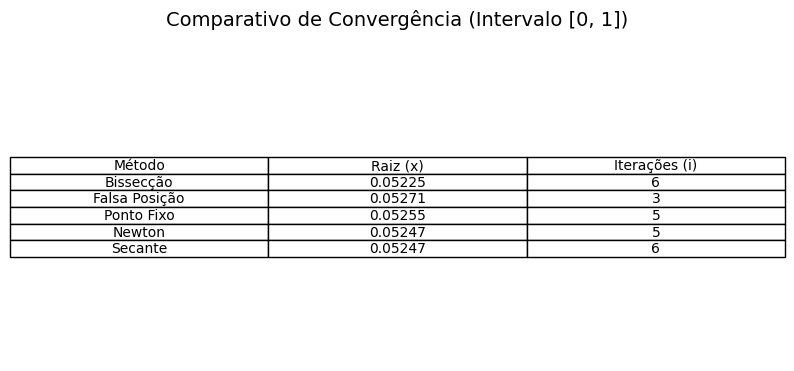

In [13]:
#Exercício
x_bi,i_bi = bisseccao_si(0,1,1e-3,lambda x:x*math.exp(-x) -math.exp(-3))
x_pf,i_pf = posi_falsa_si(0,1,1e-3,lambda x:x*math.exp(-x) -math.exp(-3))
x_pntF,i_pntF = ponto_fixo_si(0,1,1e-3,lambda x:x*math.exp(-x) -math.exp(-3))
x_n,i_n = newton_si(0,1,1e-3,lambda x:x*sp.exp(-x) -sp.exp(-3))
x_s,i_s = secante_si(0,1,1e-3,lambda x:x*math.exp(-x) -math.exp(-3))
metodos = ["Bissecção", "Falsa Posição", "Ponto Fixo", "Newton", "Secante"]
resultados = []


try: resultados.append([metodos[0], f"{x_bi:.5f}", i_bi])
except: resultados.append([metodos[0], "Fora de Intervalo", "-"])

try: resultados.append([metodos[1], f"{x_pf:.5f}", i_pf])
except: resultados.append([metodos[1], "Fora de Intervalo", "-"])

try: resultados.append([metodos[2], f"{x_pntF:.5f}", i_pntF])
except: resultados.append([metodos[2], f"{x_pntF:.5f}", i_pntF])

try: resultados.append([metodos[3], f"{x_n:.5f}", i_n])
except: resultados.append([metodos[3], f"{x_n:.5f}", i_n])

try: resultados.append([metodos[4], f"{x_s:.5f}", i_s])
except: resultados.append([metodos[4], f"{x_s:.5f}", i_s])

# Plotando a tabela
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

tabela = ax.table(cellText=resultados,
                  colLabels=["Método", "Raiz (x)", "Iterações (i)"],
                  loc='center',
                  cellLoc='center')
plt.title("Comparativo de Convergência (Intervalo [0, 1])", fontsize=14, pad=20)
plt.show()


Não chegou no erro após 4 iterações. Última aproximação foi 2.625
A raiz está em 2.717504882823696 após 4 iterações. f(raiz) = 0.000777
A raiz está em 2.718282 após 3 iterações. f(raiz) = -0.000000
A raiz está em 2.718282 após 3 iterações. f(raiz) = -0.000000
A raiz está em 2.7182780316166073 após 4 iterações. f(raiz) = 0.000004


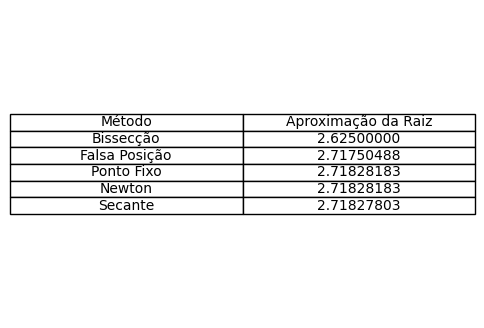

In [14]:
#Exercício 1
x1_bi,it_bi = bisseccao_(2,4,10**-3,4,lambda x:x-x*math.log(x))
x1_pf,it_pf = posi_falsa(2,4,10**-3,4,lambda x:x-x*math.log(x))
x1_pntF,it_pntF = ponto_fixo(2,4,10**-3,4,lambda x:x-x*math.log(x))
x1_n,it_n = newton_(2,4,10**-3,4,lambda x:x-x*sp.log(x))
x1_s,it_s = secante(2,4,10**-3,4,lambda x:x-x*math.log(x))

metodos = ["Bissecção", "Falsa Posição", "Ponto Fixo", "Newton", "Secante"]
aproximacoes = [
    [metodos[0], f"{x1_bi:.8f}"],
    [metodos[1], f"{x1_pf:.8f}"],
    [metodos[2], f"{x1_pntF:.8f}"],
    [metodos[3], f"{x1_n:.8f}"],
    [metodos[4], f"{x1_s:.8f}"]
]

fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('off')

# Criando a tabela
tabela = ax.table(
    cellText=aproximacoes,
    colLabels=["Método", "Aproximação da Raiz"],
    loc='center',
    cellLoc='center'
)
